In [1]:
import sys
print(sys.executable)
print(sys.version)

/opt/anaconda3/envs/supplychain/bin/python
3.12.14 | packaged by Anaconda, Inc. | (main, Aug 27 2026, 14:38:15) [Clang 20.1.8 ]


In [2]:
import pandas as pd
import numpy as np
import os

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Environment is working!")

Pandas: 3.0.5
NumPy: 2.5.2
Environment is working!


In [3]:
import os
import pandas as pd

# Path to raw data folder
DATA_PATH = "../data/raw/data_olias"

# List all files
files = os.listdir(DATA_PATH)

print("Files found:")
for file in files:
    print(file)

Files found:
olist_sellers_dataset.csv
product_category_name_translation.csv
olist_orders_dataset.csv
olist_order_items_dataset.csv
olist_customers_dataset.csv
olist_geolocation_dataset.csv
olist_order_payments_dataset.csv
olist_order_reviews_dataset.csv
olist_products_dataset.csv


In [4]:
datasets = {}

for file in files:
    if file.endswith(".csv"):
        dataset_name = file.replace(".csv", "")
        file_path = os.path.join(DATA_PATH, file)

        datasets[dataset_name] = pd.read_csv(file_path)

        print(f"\n{'='*60}")
        print(dataset_name)
        print("Shape:", datasets[dataset_name].shape)
        print("Columns:")
        print(datasets[dataset_name].columns.tolist())


olist_sellers_dataset
Shape: (3095, 4)
Columns:
['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state']

product_category_name_translation
Shape: (71, 2)
Columns:
['product_category_name', 'product_category_name_english']

olist_orders_dataset
Shape: (99441, 8)
Columns:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

olist_order_items_dataset
Shape: (112650, 7)
Columns:
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

olist_customers_dataset
Shape: (99441, 5)
Columns:
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

olist_geolocation_dataset
Shape: (1000163, 5)
Columns:
['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']

olist_order_payments_dataset
Shape: (103

In [5]:
for name, df in datasets.items():
    print(f"{name}: {df.shape}")

olist_sellers_dataset: (3095, 4)
product_category_name_translation: (71, 2)
olist_orders_dataset: (99441, 8)
olist_order_items_dataset: (112650, 7)
olist_customers_dataset: (99441, 5)
olist_geolocation_dataset: (1000163, 5)
olist_order_payments_dataset: (103886, 5)
olist_order_reviews_dataset: (99224, 7)
olist_products_dataset: (32951, 9)


# 1. Data Quality Assessment

This section examines missing values, duplicate records, and data types
across the Olist datasets before preprocessing and integration.

In [6]:
# Data quality summary

for name, df in datasets.items():
    
    print(f"\n{'='*70}")
    print(f"DATASET: {name.upper()}")
    print(f"{'='*70}")
    
    print("\nShape:")
    print(df.shape)
    
    print("\nMissing Values:")
    missing = df.isnull().sum()
    print(missing[missing > 0])
    
    print("\nDuplicate Rows:")
    print(df.duplicated().sum())
    
    print("\nData Types:")
    print(df.dtypes)


DATASET: OLIST_SELLERS_DATASET

Shape:
(3095, 4)

Missing Values:
Series([], dtype: int64)

Duplicate Rows:
0

Data Types:
seller_id                   str
seller_zip_code_prefix    int64
seller_city                 str
seller_state                str
dtype: object

DATASET: PRODUCT_CATEGORY_NAME_TRANSLATION

Shape:
(71, 2)

Missing Values:
Series([], dtype: int64)

Duplicate Rows:
0

Data Types:
product_category_name            str
product_category_name_english    str
dtype: object

DATASET: OLIST_ORDERS_DATASET

Shape:
(99441, 8)

Missing Values:
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

Duplicate Rows:
0

Data Types:
order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_da

In [7]:
orders = datasets["olist_orders_dataset"].copy()

# Convert timestamp columns
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

print("Dataset Time Range:")
print("Start:", orders["order_purchase_timestamp"].min())
print("End:", orders["order_purchase_timestamp"].max())

print("\nOrder Status Distribution:")
print(orders["order_status"].value_counts())

Dataset Time Range:
Start: 2016-09-04 21:15:19
End: 2018-10-17 17:30:18

Order Status Distribution:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [8]:
# Create a missing values summary for all datasets

missing_summary = []

for name, df in datasets.items():
    missing = df.isnull().sum()
    
    for column, count in missing.items():
        if count > 0:
            missing_summary.append({
                "Dataset": name,
                "Column": column,
                "Missing Values": count,
                "Missing Percentage": round((count / len(df)) * 100, 2)
            })

missing_df = pd.DataFrame(missing_summary)

missing_df

,Dataset,Column,Missing Values,Missing Percentage
0,olist_orders_dataset,order_approved_at,160,0.16
1,olist_orders_dataset,order_delivered_carrier_date,1783,1.79
2,olist_orders_dataset,order_delivered_customer_date,2965,2.98
3,olist_order_reviews_dataset,review_comment_title,87656,88.34
4,olist_order_reviews_dataset,review_comment_message,58247,58.70
5,olist_products_dataset,product_category_name,610,1.85
6,olist_products_dataset,product_name_lenght,610,1.85
7,olist_products_dataset,product_description_lenght,610,1.85
8,olist_products_dataset,product_photos_qty,610,1.85
9,olist_products_dataset,product_weight_g,2,0.01


# 2. Data Preprocessing

Clean and prepare the core datasets required for supply chain analysis,
including orders, order items, products, customers, sellers, payments,
and customer reviews.

In [9]:
# Create working copies

orders = datasets["olist_orders_dataset"].copy()
order_items = datasets["olist_order_items_dataset"].copy()
customers = datasets["olist_customers_dataset"].copy()
products = datasets["olist_products_dataset"].copy()
sellers = datasets["olist_sellers_dataset"].copy()
payments = datasets["olist_order_payments_dataset"].copy()
reviews = datasets["olist_order_reviews_dataset"].copy()
category_translation = datasets["product_category_name_translation"].copy()

print("Working copies created successfully!")

Working copies created successfully!


In [10]:
# Convert order-related timestamps

order_date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in order_date_columns:
    orders[col] = pd.to_datetime(orders[col])

# Convert shipping date
order_items["shipping_limit_date"] = pd.to_datetime(
    order_items["shipping_limit_date"]
)

# Convert review timestamps
review_date_columns = [
    "review_creation_date",
    "review_answer_timestamp"
]

for col in review_date_columns:
    reviews[col] = pd.to_datetime(reviews[col])

print("Date conversion completed!")

Date conversion completed!


In [11]:
# Create delivered orders dataset for core supply chain analysis

delivered_orders = orders[
    orders["order_status"] == "delivered"
].copy()

print("Total orders:", len(orders))
print("Delivered orders:", len(delivered_orders))
print(
    "Delivered order percentage:",
    round(len(delivered_orders) / len(orders) * 100, 2),
    "%"
)

Total orders: 99441
Delivered orders: 96478
Delivered order percentage: 97.02 %


In [12]:
cleaned_datasets = {
    "orders": orders,
    "order_items": order_items,
    "customers": customers,
    "products": products,
    "sellers": sellers,
    "payments": payments,
    "reviews": reviews,
    "category_translation": category_translation
}

In [13]:
# ============================================================
# STEP 4: DATA CLEANING
# ============================================================

# 1. PRODUCTS DATA
# Fill missing category with 'unknown'
products['product_category_name'] = products[
    'product_category_name'
].fillna('unknown')

# Product physical/details missing values
product_numeric_cols = [
    'product_name_lenght',
    'product_description_lenght',
    'product_photos_qty',
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm'
]

for col in product_numeric_cols:
    products[col] = products[col].fillna(products[col].median())


# 2. REVIEWS DATA
# Text reviews are not the main focus of this project
# Fill missing text fields with empty strings
reviews['review_comment_title'] = reviews[
    'review_comment_title'
].fillna('')

reviews['review_comment_message'] = reviews[
    'review_comment_message'
].fillna('')


# 3. ORDERS DATA
# Keep missing delivery dates because they represent
# canceled/unavailable/non-delivered orders


# Check missing values after cleaning
print("=" * 60)
print("MISSING VALUES AFTER CLEANING")
print("=" * 60)

for name, df in cleaned_datasets.items():
    
    missing = df.isnull().sum()
    missing = missing[missing > 0]

    if len(missing) > 0:
        print(f"\n{name.upper()}")
        print(missing)
    else:
        print(f"\n{name.upper()}: No missing values")

MISSING VALUES AFTER CLEANING

ORDERS
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

ORDER_ITEMS: No missing values

CUSTOMERS: No missing values

PRODUCTS: No missing values

SELLERS: No missing values

PAYMENTS: No missing values

REVIEWS: No missing values

CATEGORY_TRANSLATION: No missing values


# 3. Master Supply Chain Dataset Construction

This section integrates the core Olist datasets to create an
order-item-level analytical dataset for supply chain analysis.

In [14]:
# Keep only delivered orders for the core analytical dataset

master_df = delivered_orders.copy()

print("Initial delivered orders:", master_df.shape)

Initial delivered orders: (96478, 8)


In [15]:
master_df = master_df.merge(
    order_items,
    on="order_id",
    how="inner"
)

print("After merging order items:", master_df.shape)

After merging order items: (110197, 14)


In [16]:
master_df = master_df.merge(
    products,
    on="product_id",
    how="left"
)

print("After merging products:", master_df.shape)

After merging products: (110197, 22)


In [17]:
master_df = master_df.merge(
    category_translation,
    on="product_category_name",
    how="left"
)

# Use English category name where available
master_df["product_category"] = master_df[
    "product_category_name_english"
].fillna(master_df["product_category_name"])

print("After adding category translation:", master_df.shape)

After adding category translation: (110197, 24)


In [18]:
customer_info = customers[
    [
        "customer_id",
        "customer_unique_id",
        "customer_city",
        "customer_state"
    ]
]

master_df = master_df.merge(
    customer_info,
    on="customer_id",
    how="left"
)

print("After merging customers:", master_df.shape)

After merging customers: (110197, 27)


In [19]:
seller_info = sellers[
    [
        "seller_id",
        "seller_city",
        "seller_state"
    ]
].rename(
    columns={
        "seller_city": "seller_city",
        "seller_state": "seller_state"
    }
)

master_df = master_df.merge(
    seller_info,
    on="seller_id",
    how="left"
)

print("After merging sellers:", master_df.shape)

After merging sellers: (110197, 29)


In [20]:
# Aggregate payment information at order level

payment_summary = payments.groupby("order_id").agg(
    total_payment_value=("payment_value", "sum"),
    total_payment_installments=("payment_installments", "max"),
    payment_types=("payment_type", lambda x: ", ".join(x.unique()))
).reset_index()

print("Payment summary shape:", payment_summary.shape)

payment_summary.head()

Payment summary shape: (99440, 4)


,order_id,total_payment_value,total_payment_installments,payment_types
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2,credit_card
1,00018f77f2f0320c557190d7a144bdd3,259.83,3,credit_card
2,000229ec398224ef6ca0657da4fc703e,216.87,5,credit_card
3,00024acbcdf0a6daa1e931b038114c75,25.78,2,credit_card
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,3,credit_card


In [21]:
master_df = master_df.merge(
    payment_summary,
    on="order_id",
    how="left"
)

print("After merging payments:", master_df.shape)

After merging payments: (110197, 32)


In [22]:
# Check review records per order

review_counts = reviews["order_id"].value_counts()

print("Maximum reviews for a single order:", review_counts.max())

print("\nOrders with multiple reviews:")
print((review_counts > 1).sum())

Maximum reviews for a single order: 3

Orders with multiple reviews:
547


In [23]:
# Aggregate reviews at order level

review_summary = reviews.groupby("order_id").agg(
    average_review_score=("review_score", "mean"),
    review_count=("review_score", "count")
).reset_index()

print("Review summary shape:", review_summary.shape)

review_summary.head()

Review summary shape: (98673, 3)


,order_id,average_review_score,review_count
0,00010242fe8c5a6d1ba2dd792cb16214,5.0,1
1,00018f77f2f0320c557190d7a144bdd3,4.0,1
2,000229ec398224ef6ca0657da4fc703e,5.0,1
3,00024acbcdf0a6daa1e931b038114c75,4.0,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0,1


In [24]:
master_df = master_df.merge(
    review_summary,
    on="order_id",
    how="left"
)

print("After merging reviews:", master_df.shape)

After merging reviews: (110197, 34)


In [25]:
master_missing = (
    master_df.isnull()
    .sum()
    .sort_values(ascending=False)
)

master_missing[master_missing > 0]

product_category_name_english    1559
review_count                      827
average_review_score              827
order_approved_at                  15
order_delivered_customer_date       8
payment_types                       3
total_payment_installments          3
total_payment_value                 3
order_delivered_carrier_date        2
dtype: int64

In [26]:
# Final category variable

master_df["product_category"] = (
    master_df["product_category_name_english"]
    .fillna(master_df["product_category_name"])
    .fillna("unknown")
)

print(
    "Missing product categories:",
    master_df["product_category"].isna().sum()
)

Missing product categories: 0


In [27]:
master_df["review_count"] = master_df["review_count"].fillna(0)

In [28]:
master_df["has_review"] = (
    master_df["average_review_score"].notna()
).astype(int)

In [29]:
master_df["review_count"] = master_df["review_count"].fillna(0)

master_df["has_review"] = (
    master_df["average_review_score"].notna()
).astype(int)

print(
    master_df[
        ["average_review_score", "review_count", "has_review"]
    ].isnull().sum()
)

average_review_score    827
review_count              0
has_review                0
dtype: int64


In [30]:
payment_missing_orders = master_df[
    master_df["total_payment_value"].isna()
][
    [
        "order_id",
        "product_id",
        "price",
        "freight_value",
        "total_payment_value"
    ]
]

payment_missing_orders

,order_id,product_id,price,freight_value,total_payment_value
34056,bfbd0f9bdef84302105ad712db648a6c,5a6b04657a4c5ee34285d1e4619a96b4,44.99,2.83,NaN
34057,bfbd0f9bdef84302105ad712db648a6c,5a6b04657a4c5ee34285d1e4619a96b4,44.99,2.83,NaN
34058,bfbd0f9bdef84302105ad712db648a6c,5a6b04657a4c5ee34285d1e4619a96b4,44.99,2.83,NaN


In [31]:
missing_delivery_orders = master_df[
    master_df["order_delivered_customer_date"].isna()
][
    [
        "order_id",
        "order_status",
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
].drop_duplicates()

missing_delivery_orders

,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_customer_date,order_estimated_delivery_date
3291,2d1e2d5bf4dc7227b3bfebb81328c15f,delivered,2017-11-28 17:44:07,2017-11-28 17:56:40,NaT,2017-12-18
22829,f5dd62b788049ad9fc0526e3ad11a097,delivered,2018-06-20 06:58:43,2018-06-20 07:19:05,NaT,2018-07-16
48549,2ebdfc4f15f23b91474edf87475f108e,delivered,2018-07-01 17:05:11,2018-07-01 17:15:12,NaT,2018-07-30
87714,e69f75a717d64fc5ecdfae42b2e8e086,delivered,2018-07-01 22:05:55,2018-07-01 22:15:14,NaT,2018-07-30
91678,0d3268bad9b086af767785e3f0fc0133,delivered,2018-07-01 21:14:02,2018-07-01 21:29:54,NaT,2018-07-24
102597,2d858f451373b04fb5c984a1cc2defaf,delivered,2017-05-25 23:22:43,2017-05-25 23:30:16,NaT,2017-06-23
108162,ab7c89dc1bf4a1ead9d6ec1ec8968a84,delivered,2018-06-08 12:09:39,2018-06-08 12:36:39,NaT,2018-06-26
108601,20edc82cf5400ce95e1afacc25798b31,delivered,2018-06-27 16:09:12,2018-06-27 16:29:30,NaT,2018-07-19


In [32]:
# Remove records with missing actual delivery date
# from the master analytical dataset

master_df = master_df[
    master_df["order_delivered_customer_date"].notna()
].copy()

print("Master dataset shape:", master_df.shape)

Master dataset shape: (110189, 35)


In [33]:
# Check duplicate order-item combinations

duplicate_order_items = master_df.duplicated(
    subset=["order_id", "order_item_id"]
).sum()

print(
    "Duplicate order-item records:",
    duplicate_order_items
)

Duplicate order-item records: 0


# 4. Feature Engineering

Operational, temporal, and logistics-related features are created
to support demand analysis, supply chain performance evaluation,
and the subsequent circular supply chain optimization model.

In [34]:
master_df["delivery_time_days"] = (
    master_df["order_delivered_customer_date"]
    - master_df["order_purchase_timestamp"]
).dt.total_seconds() / 86400

In [35]:
master_df["delivery_delay_days"] = (
    master_df["order_delivered_customer_date"]
    - master_df["order_estimated_delivery_date"]
).dt.total_seconds() / 86400

In [36]:
master_df["is_late_delivery"] = (
    master_df["delivery_delay_days"] > 0
).astype(int)

In [37]:
master_df["product_volume_cm3"] = (
    master_df["product_length_cm"]
    * master_df["product_height_cm"]
    * master_df["product_width_cm"]
)

In [38]:
master_df["freight_ratio"] = (
    master_df["freight_value"]
    / master_df["price"]
)

In [39]:
master_df[
    [
        "delivery_time_days",
        "delivery_delay_days",
        "is_late_delivery",
        "product_volume_cm3",
        "freight_ratio"
    ]
].describe()

,delivery_time_days,delivery_delay_days,is_late_delivery,product_volume_cm3,freight_ratio
count,110189.000000,110189.000000,110189.000000,110189.000000,110189.000000
mean,12.472246,-11.331987,0.079082,15172.581946,0.320822
std,9.445346,10.160368,0.269868,23237.435429,0.347791
min,0.533414,-146.016123,0.000000,168.000000,0.000000
25%,6.736192,-16.320440,0.000000,2850.000000,0.134544
50%,10.184201,-12.046447,0.000000,6460.000000,0.231837
75%,15.540810,-6.476655,0.000000,18144.000000,0.393250
max,209.628611,188.975081,1.000000,296208.000000,26.235294


## 4.1 Temporal and Demand Features

Temporal features are created from order purchase timestamps to analyze
demand patterns across time and support subsequent forecasting and
optimization.

In [40]:
# Purchase date features

master_df["purchase_date"] = master_df[
    "order_purchase_timestamp"
].dt.date

master_df["purchase_year"] = master_df[
    "order_purchase_timestamp"
].dt.year

master_df["purchase_month"] = master_df[
    "order_purchase_timestamp"
].dt.month

master_df["purchase_quarter"] = master_df[
    "order_purchase_timestamp"
].dt.quarter

master_df["purchase_weekday"] = master_df[
    "order_purchase_timestamp"
].dt.day_name()

master_df["purchase_hour"] = master_df[
    "order_purchase_timestamp"
].dt.hour

# Year-month variable for aggregation
master_df["year_month"] = master_df[
    "order_purchase_timestamp"
].dt.to_period("M").astype(str)

print("Temporal features created successfully!")

Temporal features created successfully!


In [41]:
monthly_demand = (
    master_df
    .groupby("year_month")
    .agg(
        total_items=("order_item_id", "count"),
        unique_orders=("order_id", "nunique"),
        total_revenue=("price", "sum"),
        total_freight=("freight_value", "sum")
    )
    .reset_index()
)

monthly_demand.head(10)

,year_month,total_items,unique_orders,total_revenue,total_freight
0,2016-09,3,1,134.97,8.49
1,2016-10,313,265,40325.11,6165.55
2,2016-12,1,1,10.90,8.72
3,2017-01,913,750,111798.36,15684.01
4,2017-02,1858,1653,234223.40,37015.92
5,2017-03,2897,2546,359198.85,55132.10
6,2017-04,2569,2303,340669.68,50142.72
7,2017-05,4003,3545,489159.25,77498.15
8,2017-06,3489,3135,421923.37,68127.00
9,2017-07,4416,3872,481604.52,84694.56


In [42]:
monthly_demand.describe()

,total_items,unique_orders,total_revenue,total_freight
count,23.000000,23.000000,23.000000,23.000000
mean,4790.826087,4194.347826,574793.431739,95571.560870
std,2845.199908,2480.924124,337222.230371,58144.963571
min,1.000000,1.000000,10.900000,8.490000
25%,2733.000000,2424.500000,349934.265000,52637.410000
50%,4797.000000,4193.000000,607399.670000,93677.820000
75%,7330.000000,6453.000000,861539.220000,152236.145000
max,8474.000000,7288.000000,987648.070000,167241.990000


In [43]:
import matplotlib.pyplot as plt

print("Matplotlib is working!")

Matplotlib is working!


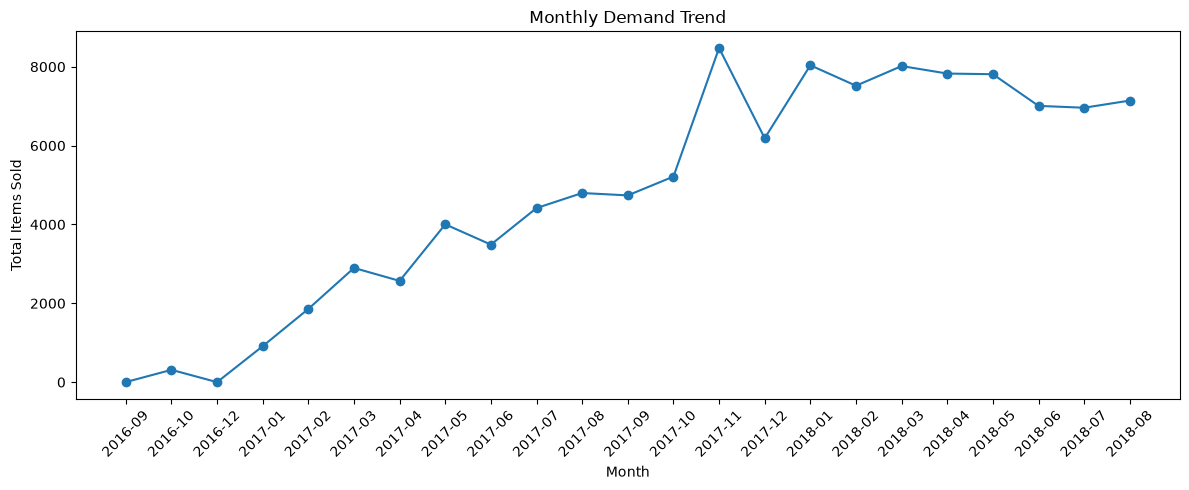

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_demand["year_month"],
    monthly_demand["total_items"],
    marker="o"
)

plt.xticks(rotation=45)

plt.title("Monthly Demand Trend")
plt.xlabel("Month")
plt.ylabel("Total Items Sold")

plt.tight_layout()
plt.show()

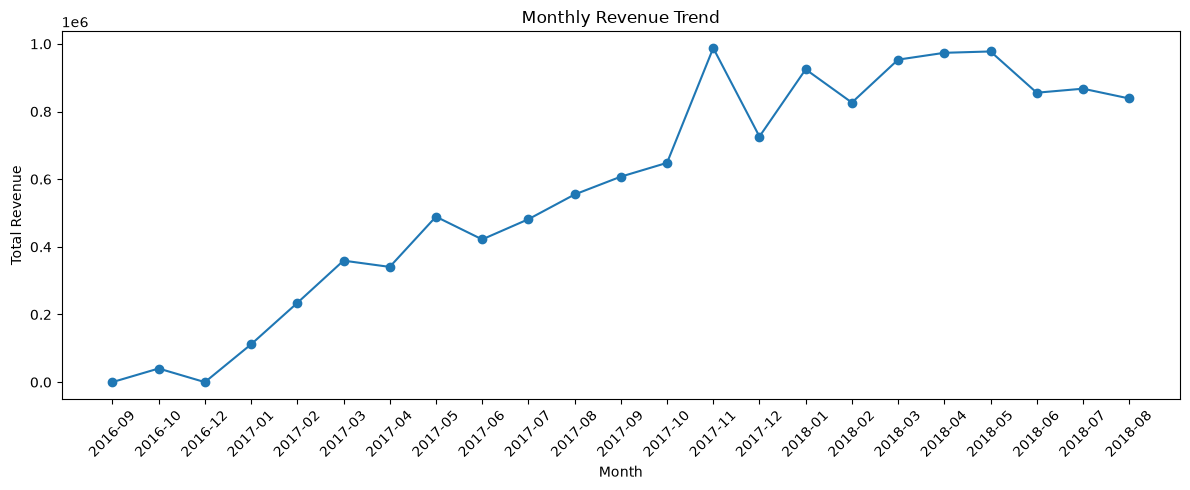

In [45]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_demand["year_month"],
    monthly_demand["total_revenue"],
    marker="o"
)

plt.xticks(rotation=45)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")

plt.tight_layout()
plt.show()

In [46]:
import os

# Create processed data directory if it doesn't exist
os.makedirs("../data/processed", exist_ok=True)

# Save master dataset
master_df.to_csv(
    "../data/processed/master_supply_chain_data.csv",
    index=False
)

# Save monthly demand dataset
monthly_demand.to_csv(
    "../data/processed/monthly_demand.csv",
    index=False
)

print("Processed datasets saved successfully!")

Processed datasets saved successfully!


## 5. Return Risk and Reverse Logistics Layer

The original Olist dataset does not contain product return information.
Therefore, a scenario-based return risk framework is developed using
observable operational and customer-service variables.

The framework is designed to simulate potential reverse logistics flows
while clearly distinguishing simulated return behavior from observed data.

In [47]:
# Create a working copy for circular supply chain modelling

circular_df = master_df.copy()

# Initialize return risk score
circular_df["return_risk_score"] = 0

In [48]:
# Low review scores indicate higher potential return risk

circular_df.loc[
    circular_df["average_review_score"] <= 2,
    "return_risk_score"
] += 3

circular_df.loc[
    circular_df["average_review_score"] == 3,
    "return_risk_score"
] += 1

In [49]:
# Late deliveries increase potential return risk

circular_df.loc[
    circular_df["is_late_delivery"] == 1,
    "return_risk_score"
] += 2

In [50]:
# Higher-value products may have greater economic incentive for returns

price_75 = circular_df["price"].quantile(0.75)

circular_df.loc[
    circular_df["price"] >= price_75,
    "return_risk_score"
] += 1

print("Return risk score created successfully!")

Return risk score created successfully!


In [51]:
circular_df["return_risk_score"].value_counts().sort_index()

return_risk_score
0    61184
1    26962
2     4172
3    10294
4     2926
5     3288
6     1363
Name: count, dtype: int64

In [52]:
# Map return risk score to scenario-based return probability

risk_probability_map = {
    0: 0.02,
    1: 0.04,
    2: 0.07,
    3: 0.12,
    4: 0.18,
    5: 0.25,
    6: 0.35
}

circular_df["return_probability"] = (
    circular_df["return_risk_score"]
    .map(risk_probability_map)
)

# Check probability distribution
circular_df[
    ["return_risk_score", "return_probability"]
].groupby(
    "return_risk_score"
).agg(
    records=("return_probability", "count"),
    return_probability=("return_probability", "first")
)

,records,return_probability
return_risk_score,,
0,61184,0.02
1,26962,0.04
2,4172,0.07
3,10294,0.12
4,2926,0.18
5,3288,0.25
6,1363,0.35


In [53]:
import numpy as np

# Set seed for reproducibility
np.random.seed(42)

# Simulate whether each item is returned
circular_df["is_returned"] = np.random.binomial(
    n=1,
    p=circular_df["return_probability"]
)

print("Return simulation completed!")

Return simulation completed!


In [54]:
return_summary = circular_df["is_returned"].value_counts()

print("Return Summary:")
print(return_summary)

print("\nSimulated Return Rate:")
print(
    round(
        circular_df["is_returned"].mean() * 100,
        2
    ),
    "%"
)

Return Summary:
is_returned
0    104622
1      5567
Name: count, dtype: int64

Simulated Return Rate:
5.05 %


## 6. Circular Recovery Pathway Modelling

For simulated returned products, multiple recovery pathways are considered.
The economic and operational characteristics of each product are used to
estimate the feasibility and value of reselling, refurbishing, recycling,
or disposal.

In [55]:
# Create recovery-related variables

circular_df["product_value"] = circular_df["price"]

# Estimated reverse logistics collection cost
circular_df["reverse_logistics_cost"] = (
    circular_df["freight_value"] * 0.80
)

# Estimated disposal cost
circular_df["disposal_cost"] = (
    circular_df["price"] * 0.05
)

# Estimated recycling recovery value
circular_df["recycling_value"] = (
    circular_df["price"] * 0.15
)

print("Recovery cost and value variables created successfully!")

Recovery cost and value variables created successfully!


In [56]:
# Default values

circular_df["resell_value"] = 0.0
circular_df["refurbishment_value"] = 0.0

In [57]:
resell_condition = (
    (circular_df["average_review_score"] >= 4)
)

circular_df.loc[
    resell_condition,
    "resell_value"
] = circular_df.loc[
    resell_condition,
    "price"
] * 0.70

In [58]:
refurbish_condition = (
    (circular_df["average_review_score"] >= 2) &
    (circular_df["average_review_score"] < 4)
)

circular_df.loc[
    refurbish_condition,
    "refurbishment_value"
] = circular_df.loc[
    refurbish_condition,
    "price"
] * 0.50

In [59]:
returns_df = circular_df[
    circular_df["is_returned"] == 1
].copy()

print("Returned items:", len(returns_df))

returns_df[
    [
        "price",
        "reverse_logistics_cost",
        "resell_value",
        "refurbishment_value",
        "recycling_value",
        "disposal_cost"
    ]
].describe()

Returned items: 5567


,price,reverse_logistics_cost,resell_value,refurbishment_value,recycling_value,disposal_cost
count,5567.000000,5567.000000,5567.000000,5567.000000,5567.000000,5567.000000
mean,149.232276,17.581097,43.237462,12.481853,22.384841,7.461614
std,236.260127,14.294623,117.509756,42.716451,35.439019,11.813006
min,1.200000,0.000000,0.000000,0.000000,0.180000,0.060000
25%,45.990000,11.280000,0.000000,0.000000,6.898500,2.299500
50%,89.900000,13.840000,0.000000,0.000000,13.485000,4.495000
75%,169.000000,18.344000,45.426500,0.000000,25.350000,8.450000
max,6729.000000,203.640000,2590.000000,957.290000,1009.350000,336.450000


In [60]:
# Create recovery score

circular_df["recovery_score"] = 0

In [61]:
# Review-based component

circular_df.loc[
    circular_df["average_review_score"] >= 4,
    "recovery_score"
] += 3

circular_df.loc[
    circular_df["average_review_score"] == 3,
    "recovery_score"
] += 2

circular_df.loc[
    circular_df["average_review_score"] <= 2,
    "recovery_score"
] += 1

In [62]:
# On-time delivery adds recovery potential

circular_df.loc[
    circular_df["is_late_delivery"] == 0,
    "recovery_score"
] += 1

In [63]:
price_median = circular_df["price"].median()

circular_df.loc[
    circular_df["price"] >= price_median,
    "recovery_score"
] += 1

In [64]:
def classify_recovery_condition(score):
    
    if score >= 5:
        return "excellent"
    
    elif score >= 4:
        return "good"
    
    elif score >= 2:
        return "repairable"
    
    else:
        return "low_recovery"

In [65]:
circular_df["recovery_condition"] = (
    circular_df["recovery_score"]
    .apply(classify_recovery_condition)
)

returns_df = circular_df[
    circular_df["is_returned"] == 1
].copy()

print(
    returns_df["recovery_condition"]
    .value_counts()
)

recovery_condition
repairable      2741
excellent       1166
good            1117
low_recovery     543
Name: count, dtype: int64


In [66]:
# Reset pathway values

returns_df["resell_value"] = 0.0
returns_df["refurbishment_value"] = 0.0

In [67]:
returns_df.loc[
    returns_df["recovery_condition"] == "excellent",
    "resell_value"
] = (
    returns_df.loc[
        returns_df["recovery_condition"] == "excellent",
        "price"
    ] * 0.75
)

In [68]:
returns_df.loc[
    returns_df["recovery_condition"] == "good",
    "resell_value"
] = (
    returns_df.loc[
        returns_df["recovery_condition"] == "good",
        "price"
    ] * 0.60
)

In [69]:
returns_df.loc[
    returns_df["recovery_condition"] == "repairable",
    "refurbishment_value"
] = (
    returns_df.loc[
        returns_df["recovery_condition"] == "repairable",
        "price"
    ] * 0.50
)

In [70]:
returns_df["recovery_condition"].value_counts()

recovery_condition
repairable      2741
excellent       1166
good            1117
low_recovery     543
Name: count, dtype: int64

In [71]:
def assign_recovery_path(condition):

    if condition == "excellent":
        return "Resell"

    elif condition == "good":
        return "Refurbish"

    elif condition == "repairable":
        return "Repair"

    else:
        return "Recycle"


returns_df["recovery_path"] = (
    returns_df["recovery_condition"]
    .apply(assign_recovery_path)
)

print("Recovery pathways created successfully!\n")

print(
    returns_df["recovery_path"]
    .value_counts()
)

Recovery pathways created successfully!

recovery_path
Repair       2741
Resell       1166
Refurbish    1117
Recycle       543
Name: count, dtype: int64


In [72]:
def calculate_recovery_value(row):

    if row["recovery_path"] == "Resell":
        return (
            row["resell_value"]
            - row["reverse_logistics_cost"]
        )

    elif row["recovery_path"] in ["Refurbish", "Repair"]:
        return (
            row["refurbishment_value"]
            - row["reverse_logistics_cost"]
        )

    elif row["recovery_path"] == "Recycle":
        return (
            row["recycling_value"]
            - row["reverse_logistics_cost"]
        )

    else:
        return -row["disposal_cost"]


# IMPORTANT: returns_df, not returned_items
returns_df["net_recovery_value"] = returns_df.apply(
    calculate_recovery_value,
    axis=1
)

print("Net recovery value calculated successfully!")

Net recovery value calculated successfully!


In [73]:
recovery_summary = (
    returns_df
    .groupby("recovery_path")
    .agg(
        total_value=("net_recovery_value", "sum"),
        average_value=("net_recovery_value", "mean"),
        item_count=("net_recovery_value", "count")
    )
    .sort_values("total_value", ascending=False)
)

recovery_summary

,total_value,average_value,item_count
recovery_path,,,
Resell,187245.8075,160.588171,1166
Repair,158840.1660,57.949714,2741
Recycle,-3206.0820,-5.904387,543
Refurbish,-16431.2240,-14.710138,1117


In [74]:
returns_df["baseline_path"] = returns_df["recovery_path"]

In [75]:
baseline_summary = recovery_summary.copy()

print(baseline_summary)

               total_value  average_value  item_count
recovery_path                                        
Resell         187245.8075     160.588171        1166
Repair         158840.1660      57.949714        2741
Recycle         -3206.0820      -5.904387         543
Refurbish      -16431.2240     -14.710138        1117


In [76]:
# Create separate processing costs

returns_df["resell_processing_cost"] = (
    returns_df["price"] * 0.05
)

returns_df["repair_processing_cost"] = (
    returns_df["price"] * 0.15
)

returns_df["refurbishment_processing_cost"] = (
    returns_df["price"] * 0.25
)

returns_df["recycling_processing_cost"] = (
    returns_df["price"] * 0.08
)

In [77]:
# Potential recovered value by pathway

returns_df["resell_revenue"] = (
    returns_df["price"] * 0.75
)

returns_df["repair_revenue"] = (
    returns_df["price"] * 0.60
)

returns_df["refurbishment_revenue"] = (
    returns_df["price"] * 0.70
)

returns_df["recycling_revenue"] = (
    returns_df["price"] * 0.15
)

In [78]:
# ============================================================
# PATHWAY-SPECIFIC PROCESSING COSTS
# ============================================================

# Resell: inspection, repackaging, handling
returns_df["resell_processing_cost"] = (
    returns_df["price"] * 0.05
)

# Repair: moderate repair/handling effort
returns_df["repair_processing_cost"] = (
    returns_df["price"] * 0.15
)

# Refurbishment: more intensive processing
returns_df["refurbishment_processing_cost"] = (
    returns_df["price"] * 0.25
)

# Recycling: dismantling and material processing
returns_df["recycling_processing_cost"] = (
    returns_df["price"] * 0.08
)


# ============================================================
# PATHWAY-SPECIFIC RECOVERED REVENUE
# ============================================================

# Resell at high recovered value
returns_df["resell_revenue"] = (
    returns_df["price"] * 0.75
)

# Repaired product resale value
returns_df["repair_revenue"] = (
    returns_df["price"] * 0.60
)

# Refurbished product resale value
returns_df["refurbishment_revenue"] = (
    returns_df["price"] * 0.70
)

# Material recovery value
returns_df["recycling_revenue"] = (
    returns_df["price"] * 0.15
)

print("Pathway-specific economics created successfully!")

Pathway-specific economics created successfully!


In [79]:
# ============================================================
# NET ECONOMIC VALUE BY PATHWAY
# ============================================================

returns_df["resell_net_value"] = (
    returns_df["resell_revenue"]
    - returns_df["reverse_logistics_cost"]
    - returns_df["resell_processing_cost"]
)

returns_df["repair_net_value"] = (
    returns_df["repair_revenue"]
    - returns_df["reverse_logistics_cost"]
    - returns_df["repair_processing_cost"]
)

returns_df["refurbishment_net_value"] = (
    returns_df["refurbishment_revenue"]
    - returns_df["reverse_logistics_cost"]
    - returns_df["refurbishment_processing_cost"]
)

returns_df["recycling_net_value"] = (
    returns_df["recycling_revenue"]
    - returns_df["reverse_logistics_cost"]
    - returns_df["recycling_processing_cost"]
)

# Disposal generates no recovered revenue
returns_df["disposal_net_value"] = (
    -returns_df["disposal_cost"]
)

print("Net pathway values calculated successfully!")

Net pathway values calculated successfully!


In [80]:
pathway_economics = returns_df[
    [
        "resell_net_value",
        "repair_net_value",
        "refurbishment_net_value",
        "recycling_net_value",
        "disposal_net_value"
    ]
].agg(["mean", "sum", "min", "max"]).T

pathway_economics

,mean,sum,min,max
resell_net_value,86.881496,483669.2880,-88.1660,4555.732
repair_net_value,49.573427,275975.2680,-123.1610,2873.482
refurbishment_net_value,49.573427,275975.2680,-123.1610,2873.482
recycling_net_value,-7.134838,-39719.6424,-176.3534,316.462
disposal_net_value,-7.461614,-41538.8040,-336.4500,-0.060


In [81]:
# ============================================================
# REVISED PATHWAY ECONOMICS
# ============================================================

# Repair
returns_df["repair_processing_cost"] = (
    returns_df["price"] * 0.12
)

returns_df["repair_revenue"] = (
    returns_df["price"] * 0.65
)


# Refurbishment
returns_df["refurbishment_processing_cost"] = (
    returns_df["price"] * 0.30
)

returns_df["refurbishment_revenue"] = (
    returns_df["price"] * 0.80
)

In [82]:
# ============================================================
# RECALCULATE NET VALUES
# ============================================================

returns_df["repair_net_value"] = (
    returns_df["repair_revenue"]
    - returns_df["reverse_logistics_cost"]
    - returns_df["repair_processing_cost"]
)

returns_df["refurbishment_net_value"] = (
    returns_df["refurbishment_revenue"]
    - returns_df["reverse_logistics_cost"]
    - returns_df["refurbishment_processing_cost"]
)

In [83]:
pathway_economics = returns_df[
    [
        "resell_net_value",
        "repair_net_value",
        "refurbishment_net_value",
        "recycling_net_value",
        "disposal_net_value"
    ]
].agg(["mean", "sum", "min", "max"]).T

pathway_economics

,mean,sum,min,max
resell_net_value,86.881496,483669.2880,-88.1660,4555.732
repair_net_value,61.512009,342437.3544,-111.9626,3411.802
refurbishment_net_value,57.035041,317514.0720,-116.1620,3209.932
recycling_net_value,-7.134838,-39719.6424,-176.3534,316.462
disposal_net_value,-7.461614,-41538.8040,-336.4500,-0.060


In [84]:
# ============================================================
# PATHWAY FEASIBILITY
# ============================================================

pathways = [
    "resell",
    "repair",
    "refurbishment",
    "recycling",
    "disposal"
]

# Initialize all pathways as infeasible
for pathway in pathways:
    returns_df[f"{pathway}_feasible"] = 0


# ------------------------------------------------------------
# EXCELLENT
# ------------------------------------------------------------

returns_df.loc[
    returns_df["recovery_condition"] == "excellent",
    ["resell_feasible", "recycling_feasible", "disposal_feasible"]
] = 1


# ------------------------------------------------------------
# GOOD
# ------------------------------------------------------------

returns_df.loc[
    returns_df["recovery_condition"] == "good",
    [
        "resell_feasible",
        "repair_feasible",
        "recycling_feasible",
        "disposal_feasible"
    ]
] = 1


# ------------------------------------------------------------
# REPAIRABLE
# ------------------------------------------------------------

returns_df.loc[
    returns_df["recovery_condition"] == "repairable",
    [
        "repair_feasible",
        "refurbishment_feasible",
        "recycling_feasible",
        "disposal_feasible"
    ]
] = 1


# ------------------------------------------------------------
# LOW RECOVERY
# ------------------------------------------------------------

returns_df.loc[
    returns_df["recovery_condition"] == "low_recovery",
    [
        "recycling_feasible",
        "disposal_feasible"
    ]
] = 1


print("Pathway feasibility matrix created successfully!")

Pathway feasibility matrix created successfully!


In [85]:
feasibility_summary = pd.DataFrame({
    pathway: returns_df[f"{pathway}_feasible"].sum()
    for pathway in pathways
}, index=["Feasible Items"]).T

feasibility_summary

,Feasible Items
resell,2283
repair,3858
refurbishment,2741
recycling,5567
disposal,5567


In [86]:
import pulp

print("PuLP version:", pulp.__version__)

PuLP version: 3.3.2


## 7. Circular Supply Chain Optimization Model

A Mixed Integer Linear Programming (MILP) model is developed to assign
each returned product to one feasible recovery pathway while maximizing
total economic recovery subject to operational capacity and sustainability
constraints.

In [87]:
import pulp
import numpy as np

# ============================================================
# DEFINE ITEMS AND PATHWAYS
# ============================================================

items = returns_df.index.tolist()

pathways = [
    "resell",
    "repair",
    "refurbishment",
    "recycling",
    "disposal"
]

print("Number of returned items:", len(items))
print("Pathways:", pathways)

Number of returned items: 5567
Pathways: ['resell', 'repair', 'refurbishment', 'recycling', 'disposal']


In [88]:
# ============================================================
# CREATE OPTIMIZATION MODEL
# ============================================================

model = pulp.LpProblem(
    "Circular_Supply_Chain_Optimization",
    pulp.LpMaximize
)

print("Optimization model created successfully!")

Optimization model created successfully!


In [89]:
# ============================================================
# DECISION VARIABLES
# ============================================================

x = pulp.LpVariable.dicts(
    "assign",
    (
        (i, p)
        for i in items
        for p in pathways
    ),
    cat="Binary"
)

print("Decision variables created successfully!")
print(
    "Total decision variables:",
    len(items) * len(pathways)
)

Decision variables created successfully!
Total decision variables: 27835


In [90]:
value_columns = {
    "resell": "resell_net_value",
    "repair": "repair_net_value",
    "refurbishment": "refurbishment_net_value",
    "recycling": "recycling_net_value",
    "disposal": "disposal_net_value"
}

In [91]:
# ============================================================
# OBJECTIVE FUNCTION
# MAXIMIZE TOTAL NET RECOVERY VALUE
# ============================================================

model += pulp.lpSum(
    
    returns_df.loc[i, value_columns[p]] * x[(i, p)]
    
    for i in items
    for p in pathways
    
), "Total_Net_Recovery_Value"

print("Objective function added successfully!")

Objective function added successfully!


In [92]:
# ============================================================
# ASSIGNMENT CONSTRAINT
# ============================================================

for i in items:
    
    model += pulp.lpSum(
        x[(i, p)]
        for p in pathways
    ) == 1

print("Assignment constraints added!")

Assignment constraints added!


In [93]:
# ============================================================
# FEASIBILITY CONSTRAINTS
# ============================================================

for i in items:
    
    for p in pathways:
        
        feasible = returns_df.loc[
            i,
            f"{p}_feasible"
        ]
        
        model += x[(i, p)] <= feasible

print("Feasibility constraints added!")

Feasibility constraints added!


In [94]:
# ============================================================
# OPERATIONAL CAPACITY CONSTRAINTS
# ============================================================

capacities = {
    "resell": 1500,
    "repair": 2000,
    "refurbishment": 1500,
    "recycling": 2500
}

for p, capacity in capacities.items():

    model += pulp.lpSum(
        x[(i, p)]
        for i in items
    ) <= capacity


print("Capacity constraints added successfully!")

Capacity constraints added successfully!


In [95]:
# ============================================================
# SUSTAINABILITY CONSTRAINT
# ============================================================

max_disposal = int(len(items) * 0.10)

model += pulp.lpSum(
    x[(i, "disposal")]
    for i in items
) <= max_disposal

print("Maximum disposal allowed:", max_disposal)
print("Sustainability constraint added successfully!")

Maximum disposal allowed: 556
Sustainability constraint added successfully!


In [96]:
print("Total variables:", len(model.variables()))
print("Total constraints:", len(model.constraints))

Total variables: 27835
Total constraints: 33407


In [97]:
# ============================================================
# SOLVE THE MILP MODEL
# ============================================================

solver = pulp.PULP_CBC_CMD(
    msg=True
)

model.solve(solver)

print("\nOptimization Status:")
print(pulp.LpStatus[model.status])

print("\nObjective Value:")
print(pulp.value(model.objective))

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /opt/anaconda3/envs/supplychain/lib/python3.12/site-packages/pulp/apis/../solverdir/cbc/osx/i64/cbc /var/folders/h9/ppllf8hs04zgbsd444t7mlr40000gn/T/9765ea816691449e8dc9cf3739f62aa7-pulp.mps -max -timeMode elapsed -solve -printingOptions all -solution /var/folders/h9/ppllf8hs04zgbsd444t7mlr40000gn/T/9765ea816691449e8dc9cf3739f62aa7-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 33412 COLUMNS
At line 200423 RHS
At line 233831 BOUNDS
At line 261667 ENDATA
Problem MODEL has 33407 rows, 27835 columns and 83505 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 391321 - 0.08 seconds
Cgl0002I 7819 variables fixed
Cgl0004I processed model has 5029 rows, 19456 columns (19456 integer (19442 of which binary)) and 38912 elements
Cbc0038I Initial state - 0 integers unsatisfied sum - 0
Cbc0038I Solution f

In [98]:
# ============================================================
# EXTRACT OPTIMAL PATHWAY ASSIGNMENTS
# ============================================================

optimal_paths = {}

for i in items:

    for p in pathways:

        if pulp.value(x[(i, p)]) == 1:

            optimal_paths[i] = p
            break


returns_df["optimal_path"] = pd.Series(optimal_paths)

print("Optimal pathway distribution:\n")

print(
    returns_df["optimal_path"]
    .value_counts()
)

Optimal pathway distribution:

optimal_path
repair           2000
resell           1500
refurbishment    1378
disposal          556
recycling         133
Name: count, dtype: int64


In [99]:
# ============================================================
# OPTIMIZED RECOVERY SUMMARY
# ============================================================

optimized_summary = (
    returns_df
    .groupby("optimal_path")
    .size()
    .reset_index(name="item_count")
)

optimized_summary

,optimal_path,item_count
0,disposal,556
1,recycling,133
2,refurbishment,1378
3,repair,2000
4,resell,1500


In [100]:
# ============================================================
# CALCULATE OPTIMIZED NET VALUE
# ============================================================

def get_optimal_value(row):
    
    return row[
        f"{row['optimal_path']}_net_value"
    ]


returns_df["optimized_net_value"] = (
    returns_df.apply(
        get_optimal_value,
        axis=1
    )
)


optimized_economic_summary = (
    returns_df
    .groupby("optimal_path")
    .agg(
        item_count=("optimal_path", "count"),
        total_net_value=("optimized_net_value", "sum"),
        average_net_value=("optimized_net_value", "mean")
    )
    .sort_values(
        "total_net_value",
        ascending=False
    )
)

optimized_economic_summary

,item_count,total_net_value,average_net_value
optimal_path,,,
resell,1500,214932.4300,143.288287
repair,2000,158135.8062,79.067903
refurbishment,1378,19623.7990,14.240783
recycling,133,-356.7316,-2.682192
disposal,556,-1014.2565,-1.824202


In [101]:
# ============================================================
# BASELINE PATH NAME MAPPING
# ============================================================

baseline_mapping = {
    "Resell": "resell",
    "Repair": "repair",
    "Refurbish": "refurbishment",
    "Recycle": "recycling",
    "Dispose": "disposal"
}

def get_baseline_value(row):
    
    pathway = baseline_mapping[row["baseline_path"]]
    
    return row[f"{pathway}_net_value"]


returns_df["baseline_net_value"] = returns_df.apply(
    get_baseline_value,
    axis=1
)

print("Baseline economics recalculated successfully!")

Baseline economics recalculated successfully!


In [102]:
baseline_economic_summary = (
    returns_df
    .groupby("baseline_path")
    .agg(
        item_count=("baseline_path", "count"),
        total_net_value=("baseline_net_value", "sum"),
        average_net_value=("baseline_net_value", "mean")
    )
    .sort_values(
        "total_net_value",
        ascending=False
    )
)

baseline_economic_summary

,item_count,total_net_value,average_net_value
baseline_path,,,
Resell,1166,173163.3430,148.510586
Repair,2741,171341.8950,62.510724
Refurbish,1117,34024.9610,30.461021
Recycle,543,-5725.2916,-10.543815


In [103]:
baseline_total = returns_df["baseline_net_value"].sum()

optimized_total = returns_df["optimized_net_value"].sum()

improvement = optimized_total - baseline_total

improvement_pct = (
    improvement / baseline_total
) * 100

print("Baseline Total Value:", round(baseline_total, 2))
print("Optimized Total Value:", round(optimized_total, 2))
print("Absolute Improvement:", round(improvement, 2))
print("Improvement Percentage:", round(improvement_pct, 2), "%")

Baseline Total Value: 372804.91
Optimized Total Value: 391321.05
Absolute Improvement: 18516.14
Improvement Percentage: 4.97 %


In [104]:
# ============================================================
# BASELINE VS OPTIMIZED COMPARISON
# ============================================================

comparison = pd.DataFrame({
    
    "Baseline": {
        "Total Net Recovery Value": baseline_total,
        "Circular Recovery Rate": (
            (returns_df["baseline_path"] != "Dispose").mean() * 100
        )
    },
    
    "Optimized": {
        "Total Net Recovery Value": optimized_total,
        "Circular Recovery Rate": (
            (returns_df["optimal_path"] != "disposal").mean() * 100
        )
    }
})

comparison["Absolute Change"] = (
    comparison["Optimized"]
    - comparison["Baseline"]
)

comparison["Percentage Change"] = (
    comparison["Absolute Change"]
    / comparison["Baseline"]
    * 100
)

comparison

,Baseline,Optimized,Absolute Change,Percentage Change
Total Net Recovery Value,372804.9074,391321.047100,18516.139700,4.966710
Circular Recovery Rate,100.0000,90.012574,-9.987426,-9.987426


In [105]:
# ============================================================
# PATHWAY DISTRIBUTION COMPARISON
# ============================================================

baseline_counts = (
    returns_df["baseline_path"]
    .value_counts()
)

optimized_counts = (
    returns_df["optimal_path"]
    .value_counts()
)


pathway_comparison = pd.DataFrame({
    
    "Baseline": {
        "Resell": baseline_counts.get("Resell", 0),
        "Repair": baseline_counts.get("Repair", 0),
        "Refurbishment": baseline_counts.get("Refurbish", 0),
        "Recycling": baseline_counts.get("Recycle", 0),
        "Disposal": baseline_counts.get("Dispose", 0)
    },
    
    "Optimized": {
        "Resell": optimized_counts.get("resell", 0),
        "Repair": optimized_counts.get("repair", 0),
        "Refurbishment": optimized_counts.get("refurbishment", 0),
        "Recycling": optimized_counts.get("recycling", 0),
        "Disposal": optimized_counts.get("disposal", 0)
    }
})

pathway_comparison

,Baseline,Optimized
Resell,1166,1500
Repair,2741,2000
Refurbishment,1117,1378
Recycling,543,133
Disposal,0,556


In [106]:
def run_circular_optimization(max_disposal_pct):

    # Create model
    scenario_model = pulp.LpProblem(
        "Circular_Supply_Chain_Scenario",
        pulp.LpMaximize
    )

    # Decision variables
    scenario_x = pulp.LpVariable.dicts(
        "assign",
        (
            (i, p)
            for i in items
            for p in pathways
        ),
        cat="Binary"
    )

    # Objective function
    scenario_model += pulp.lpSum(
        returns_df.loc[i, value_columns[p]]
        * scenario_x[(i, p)]
        for i in items
        for p in pathways
    )

    # Every item assigned exactly once
    for i in items:
        scenario_model += pulp.lpSum(
            scenario_x[(i, p)]
            for p in pathways
        ) == 1

    # Feasibility constraints
    for i in items:
        for p in pathways:

            feasible = returns_df.loc[
                i,
                f"{p}_feasible"
            ]

            scenario_model += (
                scenario_x[(i, p)] <= feasible
            )

    # Capacity constraints
    for p, capacity in capacities.items():

        scenario_model += pulp.lpSum(
            scenario_x[(i, p)]
            for i in items
        ) <= capacity

    # Disposal constraint
    max_disposal_items = int(
        len(items) * max_disposal_pct
    )

    scenario_model += pulp.lpSum(
        scenario_x[(i, "disposal")]
        for i in items
    ) <= max_disposal_items

    # Solve
    scenario_model.solve(
        pulp.PULP_CBC_CMD(msg=False)
    )

    # Extract assignments
    assignments = {}

    for i in items:
        for p in pathways:

            if pulp.value(scenario_x[(i, p)]) == 1:
                assignments[i] = p
                break

    # Pathway counts
    counts = pd.Series(assignments).value_counts()

    return {
        "max_disposal_pct": max_disposal_pct * 100,
        "objective_value": pulp.value(scenario_model.objective),
        "disposal_items": counts.get("disposal", 0),
        "circular_recovery_rate": (
            1 - counts.get("disposal", 0) / len(items)
        ) * 100,
        "resell": counts.get("resell", 0),
        "repair": counts.get("repair", 0),
        "refurbishment": counts.get("refurbishment", 0),
        "recycling": counts.get("recycling", 0)
    }

In [107]:
scenarios = {
    "Profit Focused (20%)": 0.20,
    "Balanced (10%)": 0.10,
    "Green (5%)": 0.05,
    "Highly Circular (2%)": 0.02,
    "Zero Disposal (0%)": 0.00
}

scenario_results = []

for scenario_name, disposal_limit in scenarios.items():

    result = run_circular_optimization(disposal_limit)

    result["scenario"] = scenario_name

    scenario_results.append(result)

scenario_df = pd.DataFrame(scenario_results)

scenario_df[
    [
        "scenario",
        "max_disposal_pct",
        "objective_value",
        "disposal_items",
        "circular_recovery_rate",
        "resell",
        "repair",
        "refurbishment",
        "recycling"
    ]
]

,scenario,max_disposal_pct,objective_value,disposal_items,circular_recovery_rate,resell,repair,refurbishment,recycling
0,Profit Focused (20%),20.0,392359.4873,921,83.456080,1500,2000,1131,15
1,Balanced (10%),10.0,391321.0471,556,90.012574,1500,2000,1378,133
2,Green (5%),5.0,389319.4050,278,95.006287,1500,2000,1457,332
3,Highly Circular (2%),2.0,387540.5665,111,98.006107,1500,2000,1492,464
4,Zero Disposal (0%),0.0,385064.1780,0,100.000000,1500,2000,1500,567


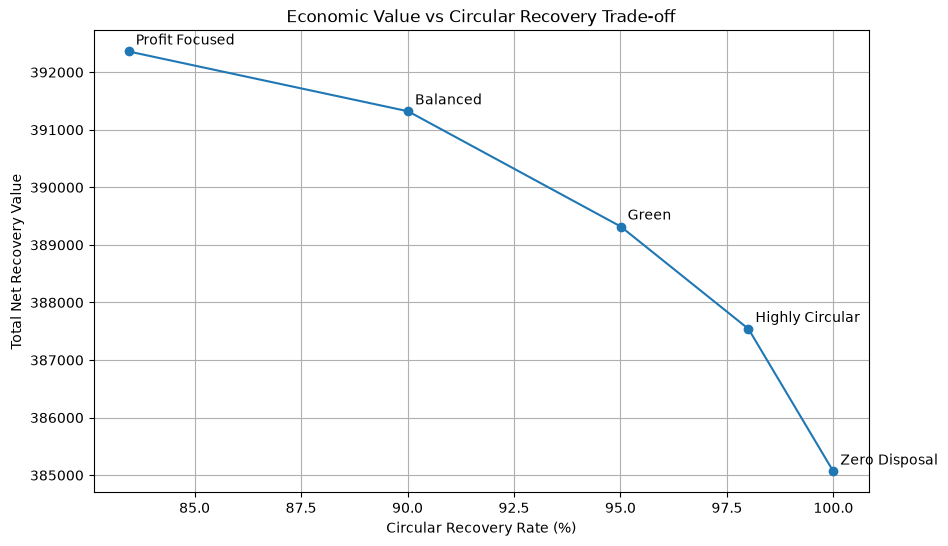

In [108]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    scenario_df["circular_recovery_rate"],
    scenario_df["objective_value"],
    marker="o"
)

for _, row in scenario_df.iterrows():

    plt.annotate(
        row["scenario"].split(" (")[0],
        (
            row["circular_recovery_rate"],
            row["objective_value"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Circular Recovery Rate (%)")
plt.ylabel("Total Net Recovery Value")

plt.title(
    "Economic Value vs Circular Recovery Trade-off"
)

plt.grid(True)

plt.show()

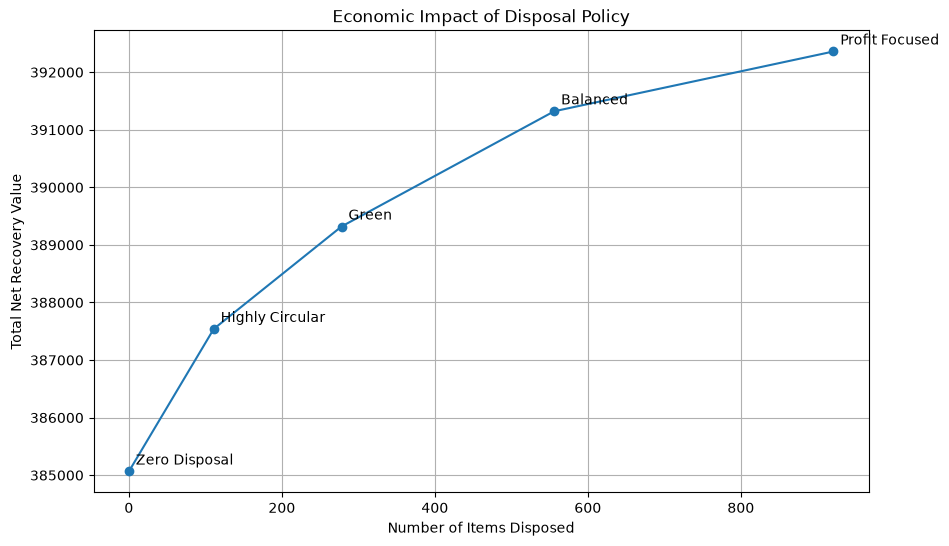

In [109]:
plt.figure(figsize=(10, 6))

plt.plot(
    scenario_df["disposal_items"],
    scenario_df["objective_value"],
    marker="o"
)

for _, row in scenario_df.iterrows():

    plt.annotate(
        row["scenario"].split(" (")[0],
        (
            row["disposal_items"],
            row["objective_value"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Number of Items Disposed")
plt.ylabel("Total Net Recovery Value")

plt.title(
    "Economic Impact of Disposal Policy"
)

plt.grid(True)

plt.show()

In [110]:
print(scenario_df.columns.tolist())

['max_disposal_pct', 'objective_value', 'disposal_items', 'circular_recovery_rate', 'resell', 'repair', 'refurbishment', 'recycling', 'scenario']


In [111]:
# ============================================================
# ECONOMIC COST OF SUSTAINABILITY ANALYSIS
# ============================================================

scenario_comparison = scenario_df.copy()

# Best economic value across all scenarios
best_value = scenario_comparison["objective_value"].max()

# Calculate economic sacrifice compared with maximum-profit scenario
scenario_comparison["economic_cost_vs_best"] = (
    best_value - scenario_comparison["objective_value"]
)

# Percentage economic cost
scenario_comparison["economic_cost_pct"] = (
    scenario_comparison["economic_cost_vs_best"] / best_value * 100
)

# Select and rename columns for presentation
decision_summary = scenario_comparison[
    [
        "scenario",
        "objective_value",
        "circular_recovery_rate",
        "disposal_items",
        "economic_cost_vs_best",
        "economic_cost_pct"
    ]
].copy()

decision_summary.columns = [
    "Scenario",
    "Net Recovery Value",
    "Circular Recovery Rate (%)",
    "Items Disposed",
    "Economic Cost vs Best",
    "Economic Cost (%)"
]

# Round numerical values
decision_summary = decision_summary.round(2)

# Display
print("=" * 75)
print("DECISION SUMMARY: PROFITABILITY vs CIRCULARITY")
print("=" * 75)

display(decision_summary)

DECISION SUMMARY: PROFITABILITY vs CIRCULARITY


,Scenario,Net Recovery Value,Circular Recovery Rate (%),Items Disposed,Economic Cost vs Best,Economic Cost (%)
0,Profit Focused (20%),392359.49,83.46,921,0.00,0.00
1,Balanced (10%),391321.05,90.01,556,1038.44,0.26
2,Green (5%),389319.40,95.01,278,3040.08,0.77
3,Highly Circular (2%),387540.57,98.01,111,4818.92,1.23
4,Zero Disposal (0%),385064.18,100.00,0,7295.31,1.86


In [112]:
# ============================================================
# RECOMMENDED MANAGEMENT POLICY
# ============================================================

balanced = scenario_comparison[
    scenario_comparison["scenario"].str.contains("Balanced")
].iloc[0]

profit_focused = scenario_comparison[
    scenario_comparison["scenario"].str.contains("Profit")
].iloc[0]

print("RECOMMENDED POLICY: BALANCED SCENARIO")
print("-" * 50)

print(
    f"Net Recovery Value: "
    f"{balanced['objective_value']:,.2f}"
)

print(
    f"Circular Recovery Rate: "
    f"{balanced['circular_recovery_rate']:.2f}%"
)

print(
    f"Items Disposed: "
    f"{balanced['disposal_items']:,}"
)

print(
    f"Economic Cost vs Profit-Focused: "
    f"{profit_focused['objective_value'] - balanced['objective_value']:,.2f}"
)

print(
    f"Circularity Improvement: "
    f"{balanced['circular_recovery_rate'] - profit_focused['circular_recovery_rate']:.2f} percentage points"
)

print(
    f"Reduction in Disposal: "
    f"{profit_focused['disposal_items'] - balanced['disposal_items']:,} items"
)

RECOMMENDED POLICY: BALANCED SCENARIO
--------------------------------------------------
Net Recovery Value: 391,321.05
Circular Recovery Rate: 90.01%
Items Disposed: 556
Economic Cost vs Profit-Focused: 1,038.44
Circularity Improvement: 6.56 percentage points
Reduction in Disposal: 365 items


In [113]:
# ============================================================
# MARGINAL COST OF CIRCULARITY
# ============================================================

analysis = scenario_comparison.sort_values(
    "circular_recovery_rate"
).copy()

analysis["additional_circularity_pp"] = (
    analysis["circular_recovery_rate"].diff()
)

analysis["additional_economic_cost"] = (
    analysis["objective_value"].shift(1)
    - analysis["objective_value"]
)

analysis["cost_per_circularity_point"] = (
    analysis["additional_economic_cost"]
    / analysis["additional_circularity_pp"]
)

marginal_analysis = analysis[
    [
        "scenario",
        "circular_recovery_rate",
        "additional_circularity_pp",
        "additional_economic_cost",
        "cost_per_circularity_point"
    ]
].copy()

marginal_analysis.columns = [
    "Scenario",
    "Circular Recovery Rate (%)",
    "Additional Circularity (pp)",
    "Additional Economic Cost",
    "Cost per Circularity Point"
]

display(marginal_analysis.round(2))

,Scenario,Circular Recovery Rate (%),Additional Circularity (pp),Additional Economic Cost,Cost per Circularity Point
0,Profit Focused (20%),83.46,NaN,NaN,NaN
1,Balanced (10%),90.01,6.56,1038.44,158.38
2,Green (5%),95.01,4.99,2001.64,400.83
3,Highly Circular (2%),98.01,3.00,1778.84,592.98
4,Zero Disposal (0%),100.00,1.99,2476.39,1241.99


## The optimization reveals a nonlinear profitability–circularity trade-off. Initial improvements in circular recovery are economically efficient, but the marginal cost rises sharply as the system approaches zero disposal.

## Moving from the Profit-Focused to Balanced policy costs only 158 units of recovery value per additional circularity percentage point, whereas the final transition toward Zero Disposal costs approximately 1,242 units per percentage point.

In [114]:
# ============================================================
# CREATE LATE DELIVERY TARGET
# ============================================================

# Check dataframe name first
print(returns_df.columns.tolist())

['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_category_name_english', 'product_category', 'customer_unique_id', 'customer_city', 'customer_state', 'seller_city', 'seller_state', 'total_payment_value', 'total_payment_installments', 'payment_types', 'average_review_score', 'review_count', 'has_review', 'delivery_time_days', 'delivery_delay_days', 'is_late_delivery', 'product_volume_cm3', 'freight_ratio', 'purchase_date', 'purchase_year', 'purchase_month', 'purchase_quarter', 'purchase_weekday', 'purchase_hour', 'year_month', 'return_risk_score', 'return_probability',

In [115]:
# ============================================================
# LATE DELIVERY TARGET DISTRIBUTION
# ============================================================

print("Late Delivery Distribution:")
print(returns_df["is_late_delivery"].value_counts())

print("\nLate Delivery Percentage:")
print(
    returns_df["is_late_delivery"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Late Delivery Distribution:
is_late_delivery
0    3867
1    1700
Name: count, dtype: int64

Late Delivery Percentage:
is_late_delivery
0    69.46
1    30.54
Name: proportion, dtype: float64


In [116]:
# Check available DataFrames and their shapes

for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        print(f"{name}: {obj.shape}")

__: (5, 2)
___: (2, 4)
df: (71, 2)
orders: (99441, 8)
missing_df: (13, 4)
_8: (13, 4)
order_items: (112650, 7)
customers: (99441, 5)
products: (32951, 9)
sellers: (3095, 4)
payments: (103886, 5)
reviews: (99224, 7)
category_translation: (71, 2)
delivered_orders: (96478, 8)
master_df: (110189, 47)
customer_info: (99441, 4)
seller_info: (3095, 3)
payment_summary: (99440, 4)
_20: (5, 4)
review_summary: (98673, 3)
_23: (5, 3)
payment_missing_orders: (3, 5)
_30: (3, 5)
missing_delivery_orders: (8, 6)
_31: (8, 6)
_39: (8, 5)
monthly_demand: (23, 5)
_41: (10, 5)
_42: (8, 4)
circular_df: (110189, 58)
_52: (7, 2)
returns_df: (5567, 82)
_59: (8, 6)
recovery_summary: (4, 3)
_73: (4, 3)
baseline_summary: (4, 3)
pathway_economics: (5, 4)
_80: (5, 4)
_83: (5, 4)
feasibility_summary: (5, 1)
_85: (5, 1)
optimized_summary: (5, 2)
_99: (5, 2)
optimized_economic_summary: (5, 3)
_100: (5, 3)
baseline_economic_summary: (4, 3)
_102: (4, 3)
comparison: (2, 4)
_104: (2, 4)
pathway_comparison: (5, 2)
_105: (5,

In [117]:
# ============================================================
# CHECK LATE DELIVERY DISTRIBUTION IN MASTER DATA
# ============================================================

print("Master Data Shape:", master_df.shape)

print("\nLate Delivery Distribution:")
print(master_df["is_late_delivery"].value_counts())

print("\nLate Delivery Percentage:")
print(
    master_df["is_late_delivery"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Master Data Shape: (110189, 47)

Late Delivery Distribution:
is_late_delivery
0    101475
1      8714
Name: count, dtype: int64

Late Delivery Percentage:
is_late_delivery
0    92.09
1     7.91
Name: proportion, dtype: float64


In [118]:
# ============================================================
# CHECK ORDER-LEVEL STRUCTURE
# ============================================================

print("Total rows:", len(master_df))
print("Unique orders:", master_df["order_id"].nunique())

print("\nDuplicate order-item rows:")
print(
    len(master_df) - master_df["order_id"].nunique()
)

print("\nMaximum items in a single order:")
print(
    master_df.groupby("order_id").size().max()
)

Total rows: 110189
Unique orders: 96470

Duplicate order-item rows:
13719

Maximum items in a single order:
21


In [119]:
# ============================================================
# CREATE ORDER-LEVEL ML DATASET
# ============================================================

order_ml = master_df.groupby("order_id").agg(

    # -----------------------------
    # TARGET
    # -----------------------------
    is_late_delivery=("is_late_delivery", "max"),

    # -----------------------------
    # ORDER / PRODUCT FEATURES
    # -----------------------------
    num_items=("order_item_id", "count"),
    num_unique_products=("product_id", "nunique"),
    num_sellers=("seller_id", "nunique"),

    total_product_value=("price", "sum"),
    avg_product_price=("price", "mean"),
    max_product_price=("price", "max"),

    total_freight_value=("freight_value", "sum"),

    total_product_weight_g=("product_weight_g", "sum"),
    total_product_volume_cm3=("product_volume_cm3", "sum"),

    avg_photos_qty=("product_photos_qty", "mean"),

    # -----------------------------
    # CUSTOMER / SELLER LOCATION
    # -----------------------------
    customer_state=("customer_state", "first"),
    seller_state=("seller_state", "first"),

    # -----------------------------
    # PAYMENT FEATURES
    # -----------------------------
    total_payment_value=("total_payment_value", "first"),
    total_payment_installments=("total_payment_installments", "first"),
    payment_type=("payment_types", "first"),

    # -----------------------------
    # TEMPORAL FEATURES
    # -----------------------------
    purchase_month=("purchase_month", "first"),
    purchase_quarter=("purchase_quarter", "first"),
    purchase_weekday=("purchase_weekday", "first"),
    purchase_hour=("purchase_hour", "first"),

    # -----------------------------
    # DATE FEATURES FOR CHECKING
    # -----------------------------
    order_purchase_timestamp=("order_purchase_timestamp", "first")
).reset_index()

print("Order-level dataset shape:", order_ml.shape)

print("\nUnique orders:", order_ml["order_id"].nunique())

print("\nLate Delivery Distribution:")
print(order_ml["is_late_delivery"].value_counts())

print("\nLate Delivery Percentage:")
print(
    order_ml["is_late_delivery"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Order-level dataset shape: (96470, 22)

Unique orders: 96470

Late Delivery Distribution:
is_late_delivery
0    88644
1     7826
Name: count, dtype: int64

Late Delivery Percentage:
is_late_delivery
0    91.89
1     8.11
Name: proportion, dtype: float64


In [120]:
# ============================================================
# ML DATASET QUALITY CHECK
# ============================================================

print("=" * 60)
print("DATASET INFO")
print("=" * 60)

print("\nShape:", order_ml.shape)

print("\nDATA TYPES:")
print(order_ml.dtypes)

print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)

missing = order_ml.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if len(missing) == 0:
    print("No missing values!")
else:
    missing_pct = (
        missing / len(order_ml) * 100
    ).round(2)

    print(
        pd.DataFrame({
            "Missing Values": missing,
            "Missing %": missing_pct
        })
    )


print("\n" + "=" * 60)
print("CATEGORICAL FEATURES")
print("=" * 60)

categorical_cols = order_ml.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

for col in categorical_cols:
    print(f"\n{col}")
    print("Unique values:", order_ml[col].nunique())
    print(order_ml[col].value_counts().head(10))


print("\n" + "=" * 60)
print("NUMERICAL SUMMARY")
print("=" * 60)

print(
    order_ml.select_dtypes(
        include=["int64", "float64"]
    ).describe().T
)

DATASET INFO

Shape: (96470, 22)

DATA TYPES:
order_id                                 str
is_late_delivery                       int64
num_items                              int64
num_unique_products                    int64
num_sellers                            int64
total_product_value                  float64
avg_product_price                    float64
max_product_price                    float64
total_freight_value                  float64
total_product_weight_g               float64
total_product_volume_cm3             float64
avg_photos_qty                       float64
customer_state                           str
seller_state                             str
total_payment_value                  float64
total_payment_installments           float64
payment_type                             str
purchase_month                         int32
purchase_quarter                       int32
purchase_weekday                         str
purchase_hour                          int32
order_pur

In [121]:
missing = order_ml.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print(missing)

print("\nMissing Percentage:")
print((missing / len(order_ml) * 100).round(2))

total_payment_value           1
total_payment_installments    1
payment_type                  1
dtype: int64

Missing Percentage:
total_payment_value           0.0
total_payment_installments    0.0
payment_type                  0.0
dtype: float64


In [122]:
categorical_cols = [
    "customer_state",
    "seller_state",
    "payment_type"
]

for col in categorical_cols:
    print(f"\n{'='*50}")
    print(col)
    print("Unique values:", order_ml[col].nunique())
    print(order_ml[col].value_counts().head(10))


customer_state
Unique values: 27
customer_state
SP    40494
RJ    12350
MG    11354
RS     5344
PR     4923
SC     3546
BA     3256
DF     2080
ES     1995
GO     1957
Name: count, dtype: int64

seller_state
Unique values: 22
seller_state
SP    68415
MG     7647
PR     7429
RJ     4185
SC     3551
RS     1949
DF      803
BA      549
GO      451
PE      403
Name: count, dtype: int64

payment_type
Unique values: 7
payment_type
credit_card                72115
boleto                     19191
voucher                     1498
debit_card                  1483
credit_card, voucher        1097
voucher, credit_card        1084
credit_card, debit_card        1
Name: count, dtype: int64


In [123]:
# ============================================================
# CLEAN PAYMENT TYPE FEATURE
# ============================================================

def clean_payment_type(x):
    
    if pd.isna(x):
        return "unknown"
    
    # Split multiple payment methods
    methods = [m.strip() for m in str(x).split(",")]
    
    # Sort so combinations are consistent
    methods = sorted(methods)
    
    return "_".join(methods)


order_ml["payment_type_clean"] = (
    order_ml["payment_type"]
    .apply(clean_payment_type)
)

print("Original unique payment types:")
print(order_ml["payment_type"].nunique())

print("\nCleaned unique payment types:")
print(order_ml["payment_type_clean"].nunique())

print("\nCleaned distribution:")
print(order_ml["payment_type_clean"].value_counts().head(15))

Original unique payment types:
7

Cleaned unique payment types:
7

Cleaned distribution:
payment_type_clean
credit_card               72115
boleto                    19191
credit_card_voucher        2181
voucher                    1498
debit_card                 1483
credit_card_debit_card        1
unknown                       1
Name: count, dtype: int64


In [124]:
numerical_features = [
    "num_items",
    "num_unique_products",
    "num_sellers",
    "total_product_value",
    "avg_product_price",
    "max_product_price",
    "total_freight_value",
    "total_product_weight_g",
    "total_product_volume_cm3",
    "avg_photos_qty",
    "total_payment_value",
    "total_payment_installments",
    "purchase_month",
    "purchase_quarter",
    "purchase_weekday",
    "purchase_hour"
]

In [125]:
categorical_features = [
    "customer_state",
    "seller_state",
    "payment_type_clean"
]

In [126]:
target = "is_late_delivery"

In [127]:
# ============================================================
# FINAL ML DATASET PREPARATION
# ============================================================

# Clean payment type
def clean_payment_type(x):

    if pd.isna(x):
        return "unknown"

    methods = [m.strip() for m in str(x).split(",")]
    methods = sorted(methods)

    return "_".join(methods)


order_ml["payment_type_clean"] = (
    order_ml["payment_type"]
    .apply(clean_payment_type)
)


# ------------------------------------------------------------
# DEFINE FEATURES
# ------------------------------------------------------------

numerical_features = [
    "num_items",
    "num_unique_products",
    "num_sellers",
    "total_product_value",
    "avg_product_price",
    "max_product_price",
    "total_freight_value",
    "total_product_weight_g",
    "total_product_volume_cm3",
    "avg_photos_qty",
    "total_payment_value",
    "total_payment_installments",
    "purchase_month",
    "purchase_quarter",
    "purchase_weekday",
    "purchase_hour"
]


categorical_features = [
    "customer_state",
    "seller_state",
    "payment_type_clean"
]


# Final feature list
feature_columns = numerical_features + categorical_features

# Create X and y
X = order_ml[feature_columns].copy()

y = order_ml["is_late_delivery"].copy()


# ------------------------------------------------------------
# TRAIN / TEST SPLIT
# ------------------------------------------------------------

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print("=" * 60)
print("TRAIN / TEST SPLIT")
print("=" * 60)

print(f"Training samples: {X_train.shape[0]:,}")
print(f"Testing samples:  {X_test.shape[0]:,}")

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).mul(100).round(2))

TRAIN / TEST SPLIT
Training samples: 77,176
Testing samples:  19,294

Training target distribution:
is_late_delivery
0    91.89
1     8.11
Name: proportion, dtype: float64

Testing target distribution:
is_late_delivery
0    91.89
1     8.11
Name: proportion, dtype: float64


In [128]:
class_weight="balanced"

In [130]:
print(X_train[numerical_features].dtypes)

num_items                       int64
num_unique_products             int64
num_sellers                     int64
total_product_value           float64
avg_product_price             float64
max_product_price             float64
total_freight_value           float64
total_product_weight_g        float64
total_product_volume_cm3      float64
avg_photos_qty                float64
total_payment_value           float64
total_payment_installments    float64
purchase_month                  int32
purchase_quarter                int32
purchase_weekday                  str
purchase_hour                   int32
dtype: object


In [131]:
# ============================================================
# CORRECT FEATURE TYPES
# ============================================================

numerical_features = [
    "num_items",
    "num_unique_products",
    "num_sellers",
    "total_product_value",
    "avg_product_price",
    "max_product_price",
    "total_freight_value",
    "total_product_weight_g",
    "total_product_volume_cm3",
    "avg_photos_qty",
    "total_payment_value",
    "total_payment_installments",
    "purchase_month",
    "purchase_quarter",
    "purchase_hour"
]


categorical_features = [
    "customer_state",
    "seller_state",
    "payment_type_clean",
    "purchase_weekday"
]

In [132]:
# ============================================================
# LOGISTIC REGRESSION BASELINE PIPELINE
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression


# ------------------------------------------------------------
# NUMERICAL PIPELINE
# ------------------------------------------------------------

numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


# ------------------------------------------------------------
# CATEGORICAL PIPELINE
# ------------------------------------------------------------

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])


# ------------------------------------------------------------
# COMBINE PREPROCESSING
# ------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


# ------------------------------------------------------------
# LOGISTIC REGRESSION MODEL
# ------------------------------------------------------------

logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])


# ------------------------------------------------------------
# TRAIN MODEL
# ------------------------------------------------------------

logistic_model.fit(X_train, y_train)

print("Logistic Regression training completed successfully!")

Logistic Regression training completed successfully!


In [133]:
# ============================================================
# LOGISTIC REGRESSION EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

# ------------------------------------------------------------
# PREDICTIONS
# ------------------------------------------------------------

y_pred = logistic_model.predict(X_test)

y_prob = logistic_model.predict_proba(X_test)[:, 1]


# ------------------------------------------------------------
# METRICS
# ------------------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

roc_auc = roc_auc_score(y_test, y_prob)

pr_auc = average_precision_score(y_test, y_prob)


print("=" * 60)
print("LOGISTIC REGRESSION PERFORMANCE")
print("=" * 60)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")
print(f"PR-AUC:    {pr_auc:.4f}")


# ------------------------------------------------------------
# CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(classification_report(
    y_test,
    y_pred,
    target_names=["On-Time", "Late Delivery"]
))


# ------------------------------------------------------------
# CONFUSION MATRIX
# ------------------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

print(cm)

LOGISTIC REGRESSION PERFORMANCE
Accuracy:  0.6371
Precision: 0.1239
Recall:    0.5719
F1 Score:  0.2036
ROC-AUC:   0.6496
PR-AUC:    0.1428

CLASSIFICATION REPORT
               precision    recall  f1-score   support

      On-Time       0.94      0.64      0.77     17729
Late Delivery       0.12      0.57      0.20      1565

     accuracy                           0.64     19294
    macro avg       0.53      0.61      0.48     19294
 weighted avg       0.88      0.64      0.72     19294


CONFUSION MATRIX
[[11398  6331]
 [  670   895]]


In [134]:
# ============================================================
# RANDOM FOREST MODEL
# ============================================================

from sklearn.ensemble import RandomForestClassifier


# ------------------------------------------------------------
# RANDOM FOREST PIPELINE
# ------------------------------------------------------------

rf_model = Pipeline(steps=[
    
    ("preprocessor", preprocessor),
    
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])


# ------------------------------------------------------------
# TRAIN RANDOM FOREST
# ------------------------------------------------------------

rf_model.fit(X_train, y_train)

print("Random Forest training completed successfully!")

Random Forest training completed successfully!


In [135]:
# ============================================================
# RANDOM FOREST EVALUATION
# ============================================================

# Predictions
rf_pred = rf_model.predict(X_test)

rf_prob = rf_model.predict_proba(X_test)[:, 1]


# ------------------------------------------------------------
# METRICS
# ------------------------------------------------------------

rf_accuracy = accuracy_score(y_test, rf_pred)

rf_precision = precision_score(
    y_test,
    rf_pred,
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    rf_pred,
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    rf_pred,
    zero_division=0
)

rf_roc_auc = roc_auc_score(y_test, rf_prob)

rf_pr_auc = average_precision_score(y_test, rf_prob)


print("=" * 60)
print("RANDOM FOREST PERFORMANCE")
print("=" * 60)

print(f"Accuracy:  {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1 Score:  {rf_f1:.4f}")
print(f"ROC-AUC:   {rf_roc_auc:.4f}")
print(f"PR-AUC:    {rf_pr_auc:.4f}")


# ------------------------------------------------------------
# CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(classification_report(
    y_test,
    rf_pred,
    target_names=["On-Time", "Late Delivery"]
))


# ------------------------------------------------------------
# CONFUSION MATRIX
# ------------------------------------------------------------

rf_cm = confusion_matrix(y_test, rf_pred)

print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

print(rf_cm)

RANDOM FOREST PERFORMANCE
Accuracy:  0.7844
Precision: 0.1913
Recall:    0.5137
F1 Score:  0.2788
ROC-AUC:   0.7280
PR-AUC:    0.2203

CLASSIFICATION REPORT
               precision    recall  f1-score   support

      On-Time       0.95      0.81      0.87     17729
Late Delivery       0.19      0.51      0.28      1565

     accuracy                           0.78     19294
    macro avg       0.57      0.66      0.58     19294
 weighted avg       0.89      0.78      0.83     19294


CONFUSION MATRIX
[[14330  3399]
 [  761   804]]


In [136]:
# ============================================================
# RANDOM FOREST THRESHOLD ANALYSIS
# ============================================================

import numpy as np
import pandas as pd

threshold_results = []

thresholds = np.arange(0.20, 0.71, 0.05)

for threshold in thresholds:
    
    threshold_pred = (rf_prob >= threshold).astype(int)
    
    threshold_results.append({
        "Threshold": round(threshold, 2),
        "Precision": precision_score(
            y_test,
            threshold_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            threshold_pred,
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_test,
            threshold_pred,
            zero_division=0
        ),
        "Late Alerts": threshold_pred.sum()
    })


threshold_df = pd.DataFrame(threshold_results)

# Convert metrics to percentages for easier interpretation
display(
    threshold_df.style.format({
        "Precision": "{:.2%}",
        "Recall": "{:.2%}",
        "F1 Score": "{:.2%}"
    })
)

,Threshold,Precision,Recall,F1 Score,Late Alerts
0,0.200000,8.26%,99.55%,15.26%,18854
1,0.250000,8.69%,97.57%,15.96%,17569
2,0.300000,9.63%,93.35%,17.46%,15171
3,0.350000,11.30%,84.60%,19.93%,11722
4,0.400000,13.63%,73.04%,22.97%,8386
5,0.450000,16.49%,61.28%,25.99%,5816
6,0.500000,19.13%,51.37%,27.88%,4203
7,0.550000,22.34%,41.92%,29.14%,2937
8,0.600000,26.04%,33.61%,29.34%,2020
9,0.650000,28.97%,25.75%,27.27%,1391


In [137]:
try:
    import xgboost
    print("XGBoost available!")
    print("Version:", xgboost.__version__)
except ImportError:
    print("XGBoost not installed")

XGBoost not installed


In [138]:
import xgboost
print(xgboost.__version__)

3.4.1


In [139]:
# ============================================================
# XGBOOST MODEL
# ============================================================

from xgboost import XGBClassifier


xgb_model = Pipeline(steps=[
    
    ("preprocessor", preprocessor),
    
    ("model", XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        
        objective="binary:logistic",
        eval_metric="logloss",
        
        random_state=42,
        n_jobs=-1
    ))
])


# ------------------------------------------------------------
# TRAIN MODEL
# ------------------------------------------------------------

xgb_model.fit(X_train, y_train)

print("XGBoost training completed successfully!")

XGBoost training completed successfully!


In [140]:
# ============================================================
# XGBOOST EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

# ------------------------------------------------------------
# PREDICTIONS
# ------------------------------------------------------------

xgb_pred = xgb_model.predict(X_test)

xgb_prob = xgb_model.predict_proba(X_test)[:, 1]


# ------------------------------------------------------------
# METRICS
# ------------------------------------------------------------

xgb_accuracy = accuracy_score(y_test, xgb_pred)

xgb_precision = precision_score(
    y_test,
    xgb_pred,
    zero_division=0
)

xgb_recall = recall_score(
    y_test,
    xgb_pred,
    zero_division=0
)

xgb_f1 = f1_score(
    y_test,
    xgb_pred,
    zero_division=0
)

xgb_roc_auc = roc_auc_score(
    y_test,
    xgb_prob
)

xgb_pr_auc = average_precision_score(
    y_test,
    xgb_prob
)


# ------------------------------------------------------------
# RESULTS
# ------------------------------------------------------------

print("=" * 60)
print("XGBOOST PERFORMANCE")
print("=" * 60)

print(f"Accuracy:  {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall:    {xgb_recall:.4f}")
print(f"F1 Score:  {xgb_f1:.4f}")
print(f"ROC-AUC:   {xgb_roc_auc:.4f}")
print(f"PR-AUC:    {xgb_pr_auc:.4f}")


# ------------------------------------------------------------
# CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        xgb_pred,
        target_names=["On-Time", "Late Delivery"]
    )
)


# ------------------------------------------------------------
# CONFUSION MATRIX
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

xgb_cm = confusion_matrix(y_test, xgb_pred)

print(xgb_cm)

XGBOOST PERFORMANCE
Accuracy:  0.9185
Precision: 0.4429
Recall:    0.0198
F1 Score:  0.0379
ROC-AUC:   0.7338
PR-AUC:    0.2244

CLASSIFICATION REPORT
               precision    recall  f1-score   support

      On-Time       0.92      1.00      0.96     17729
Late Delivery       0.44      0.02      0.04      1565

     accuracy                           0.92     19294
    macro avg       0.68      0.51      0.50     19294
 weighted avg       0.88      0.92      0.88     19294


CONFUSION MATRIX
[[17690    39]
 [ 1534    31]]
